# OpenCV Quest #1   (김민수)

In [82]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import dlib

1. 이미지 로딩 및 얼굴 부위 인식

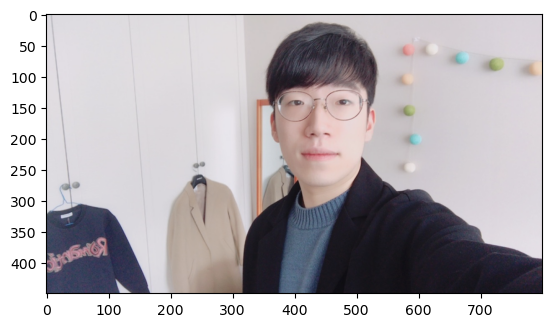

In [111]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, 'work/camera_sticker/images/image.png') # 본인 이미지가 있는 경로를 가지고 온다.
img_bgr = cv2.imread(my_image_path)    
img_show = img_bgr.copy()               # 출력용 이미지를 따로 보관.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

rectangles[[(345, 98) (531, 284)]]


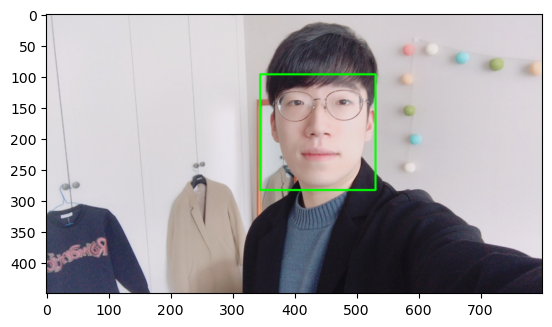

In [112]:
detector_hog = dlib.get_frontal_face_detector()     # 기본 얼굴 감지기를 반환
dlib_rects = detector_hog(img_rgb, 1)               # (image, num of image pyramid)
print(dlib_rects)                                   # 찾은 얼굴 영역 박스 리스트

for dlib_rect in dlib_rects:   # 얼굴영역 좌표
    l = dlib_rect.left()       # 왼쪽
    t = dlib_rect.top()        # 위쪽
    r = dlib_rect.right()      # 오른쪽
    b = dlib_rect.bottom()     # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)    # 시작점, 종료점 좌표로 직각 사각형 표시

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

2. 랜드마크 위치 검출

68


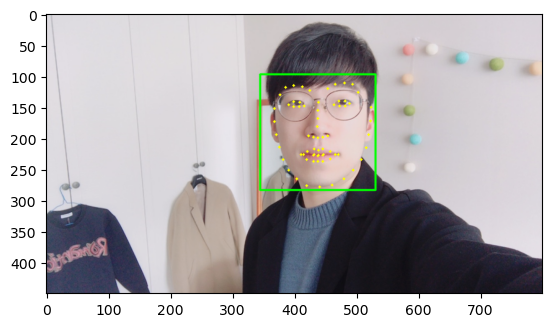

In [113]:
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')  #landmark 모델주소를 model_path에 저장

landmark_predictor = dlib.shape_predictor(model_path)   # shape_predictor 함수를 이용해 모델 호출: RGB이미지와 dlib.rectangle를 입력받고 dlib.full_object_detection를 반환
                                                        # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체 위치

list_landmarks = []                                     # 랜드마크 위치를 list 변수에 저장

for dlib_rect in dlib_rects:                            # 얼굴영역 박스 마다 face landmark 탐색 (face landmark 좌표 저장)
    points = landmark_predictor(img_rgb, dlib_rect)     # 모든 landmark의 위치정보를 points 변수에 저장
 
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))  # landmark 위치정보를 (x,y) 형태로 list_points 리스트에 저장  
    list_landmarks.append(list_points)                             # list_landmarks에 랜드마크 리스트를 저장
       
print(len(list_landmarks[0]))                          # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고, 각 원소는 68개의 랜드마크 위치가 나열된 list


for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)  # 크기 2, yellow 컬러로 내부가 채워진(-1)원을 그림

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

3. 스티커 위치 선정 및 Size 조정

In [114]:
for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴영역 정보를 가진 dlib_rect 변수와 랜드마크 값을 가진 list_landmarks 변수로 반복문 수행.
    print (landmark[33])                                    # 코끝 위치 index = 33
    x = landmark[33][0]                                     # 코끝 위치 x값
    y = landmark[33][1]                                     # 코끝 위치 y값  (- dlib_rect.height()//2)
    w = dlib_rect.width()                               # 얼굴영역의 가로부위 픽셀 수 = (531-345+1) → max(x) - min(x) +1 (픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    h = round(dlib_rect.width()/2)                      # 수염 이미지의 세로 size를 조정
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(438, 200)
(x,y) : (438,200)
(w,h) : (187,94)


4. 스티커 이미지 로드 및 조건부 crop 설정

In [87]:
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/cat-whiskers.png')  # 수염 이미지 경로
img_sticker = cv2.imread(sticker_path)                     # 스티커 이미지를 로딩 // cv2.imread(이미지 경로) → image객체 행렬을 반환
img_sticker = cv2.resize(img_sticker, (w, h))               # 스티커 이미지 조정 → w,h는 얼굴 영역의 가로를 차지하는 픽셀의 수(187) // cv2.resize(image객체 행렬, (가로 길이, 세로 길이))
print (img_sticker.shape)                                  # Resized 수염 이미지의 차원 확인

(94, 187, 3)


In [115]:
# 원본 이미지에 스티커 이미지를 추가하기 위해서 x, y 좌표를 조정. 이미지 시작점은 top-left 좌표.
refined_x = x - w // 2      
refined_y = int(y - h // 1.8)       
print (f'(refined x, refined y) : ({refined_x},{refined_y})')    # 양수 이므로 crop 작업 불필요. 

# (만약, 음수일 땐 음수값 만큼 왕관 이미지 crop함: 수염 이미지를 씌우기 위해 수염 이미지가 시작할 y좌표 값 조정)
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :]      
    refined_y = 0

print (f'(refined x, refined y) : ({refined_x},{refined_y})')

(refined x, refined y) : (345,148)
(refined x, refined y) : (345,148)


5. 스티커와 원본 이미지 합치기

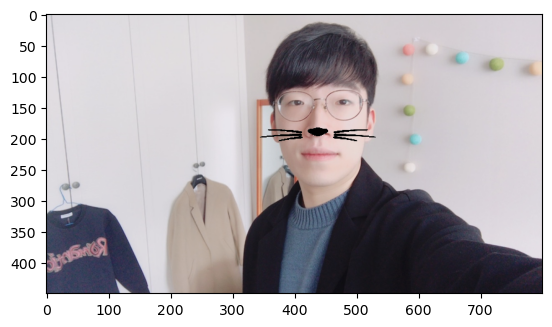

In [117]:
# sticker_area는 원본이미지에서 스티커를 적용할 위치를 crop한 이미지.
img_show = img_bgr.copy()
sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]

# 수염 이미지에서 0이 나오는 부분은 이미지가 없다는 의미 => 0인 부분(이미지가 없는 부분)은 제외하고 나머지 부분은 스티커로 채우기.
# img_sticker가 0일 경우(수염 이미지에서 수염부분 제외한 나머지 이미지)에는 sticker_area를 적용.

img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==255,sticker_area,img_sticker).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

6. 다른 각도의 얼굴 이미지로 추가 테스트 

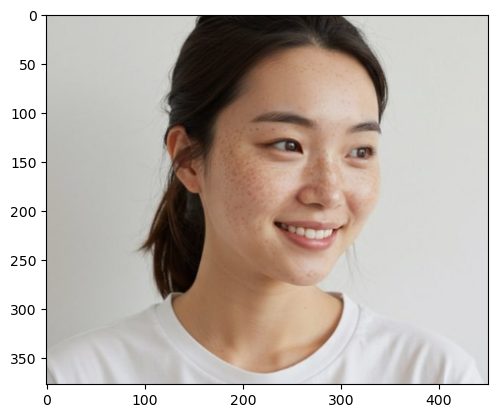

In [129]:
home_dir = os.getenv('HOME')
img2_path = os.path.join(home_dir, 'work/camera_sticker/images/face image_sample2.png') # 다른 각도 이미지 로딩
img2_bgr = cv2.imread(img2_path)    
img2_show = img2_bgr.copy()               # 출력용 이미지를 따로 보관.
img3_show = img2_bgr.copy() 
img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img2_rgb)
plt.show()

rectangles[[(180, 77) (366, 263)]]
68


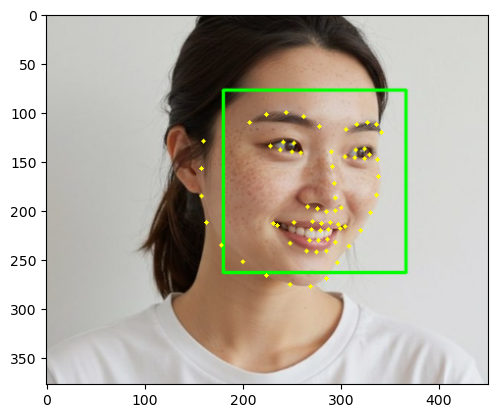

In [130]:
detector_hog = dlib.get_frontal_face_detector()     # 기본 얼굴 감지기를 반환
dlib_rects2 = detector_hog(img2_rgb, 1)               # (image, num of image pyramid)
print(dlib_rects2)                                   # 찾은 얼굴 영역 박스 리스트

for dlib_rect2 in dlib_rects2:   # 얼굴영역 좌표
    l = dlib_rect2.left()       # 왼쪽
    t = dlib_rect2.top()        # 위쪽
    r = dlib_rect2.right()      # 오른쪽
    b = dlib_rect2.bottom()     # 아래쪽

    cv2.rectangle(img2_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)    # 시작점, 종료점 좌표로 직각 사각형 표시

# img2_show_rgb =  cv2.cvtColor(img2_show, cv2.COLOR_BGR2RGB)

model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')  #landmark 모델주소를 model_path에 저장

landmark_predictor = dlib.shape_predictor(model_path)   # shape_predictor 함수를 이용해 모델 호출: RGB이미지와 dlib.rectangle를 입력받고 dlib.full_object_detection를 반환
                                                        # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체 위치

list_landmarks2 = []                                     # 랜드마크 위치를 list 변수에 저장

for dlib_rect2 in dlib_rects2:                            # 얼굴영역 박스 마다 face landmark 탐색 (face landmark 좌표 저장)
    points2 = landmark_predictor(img2_rgb, dlib_rect2)     # 모든 landmark2의 위치정보를 points 변수에 저장
 
    list_points2 = list(map(lambda p: (p.x, p.y), points2.parts()))  # landmark2 위치정보를 (x,y) 형태로 list_points 리스트에 저장  
    list_landmarks2.append(list_points2)                             # list_landmarks2에 랜드마크 리스트를 저장
       
print(len(list_landmarks2[0]))                          # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고, 각 원소는 68개의 랜드마크 위치가 나열된 list


for landmark2 in list_landmarks2:
    for point2 in landmark2:
        cv2.circle(img2_show, point2, 2, (0, 255, 255), -1)  # 크기 2, yellow 컬러로 내부가 채워진(-1)원을 그림

img2_show_rgb = cv2.cvtColor(img2_show, cv2.COLOR_BGR2RGB)
plt.imshow(img2_show_rgb)
plt.show()

In [131]:
for dlib_rect2, landmark2 in zip(dlib_rects2, list_landmarks2): 
    print (landmark2[33])                                     # 코끝 위치 index = 33
    x2 = landmark2[33][0]                                     # 코끝 위치 x값
    y2 = landmark2[33][1]                                     # 코끝 위치 y값  
    w2 = dlib_rect2.width()                                    # 얼굴영역의 가로부위 픽셀 수
    h2 = round(dlib_rect2.width()/2)                           # 수염 이미지의 세로 size를 조정
    print (f'(x,y) : ({x2},{y2})')
    print (f'(w,h) : ({w2},{h2})')

sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/cat-whiskers.png')  
img_sticker2 = cv2.imread(sticker_path)                      # 스티커 이미지를 로딩 
img_sticker2 = cv2.resize(img_sticker2, (w2, h2))            # 스티커 이미지 조정 
print (img_sticker2.shape)                                   # Resized 수염 이미지의 차원 확인

(285, 201)
(x,y) : (285,201)
(w,h) : (187,94)
(94, 187, 3)


In [132]:
# 원본 이미지에 스티커 이미지를 추가하기 위해서 x, y 좌표를 조정. 이미지 시작점은 top-left 좌표.
refined_x2 = x2 - w2 // 2      
refined_y2 = int(y2 - h2 // 1.8)         
print (f'(refined x, refined y) : ({refined_x2},{refined_y2})')    # 양수 이므로 crop 작업 불필요. 

# (만약, 음수일 땐 음수값 만큼 왕관 이미지 crop함: 수염 이미지를 씌우기 위해 수염 이미지가 시작할 y좌표 값 조정)
if refined_x2 < 0:
    img_sticker2 = img_sticker2[:, -refined_x2:]
    refined_x2 = 0
if refined_y2 < 0:
    img_sticker2 = img_sticker2[-refined_y2:, :]      
    refined_y2 = 0

print (f'(refined x, refined y) : ({refined_x2},{refined_y2})')

(refined x, refined y) : (192,149)
(refined x, refined y) : (192,149)


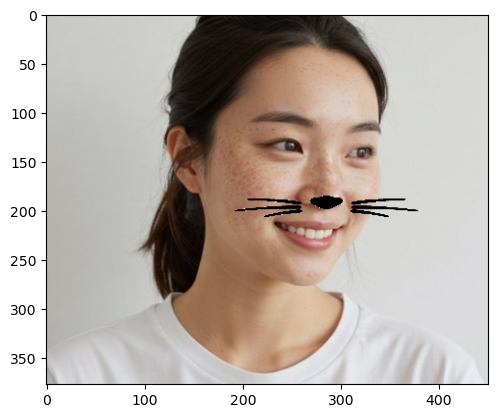

In [123]:
img2_show =img2_bgr

# sticker_area는 원본이미지에서 스티커를 적용할 위치를 crop한 이미지.
sticker_area2 = img2_show[refined_y2:refined_y2+img_sticker2.shape[0], refined_x2:refined_x2+img_sticker2.shape[1]]

# 수염 이미지에서 0이 나오는 부분(이미지가 없는 부분)은 제외하고 나머지 부분은 스티커로 채우기.
# img_sticker2가 0일 경우(수염 이미지에서 수염부분 제외한 나머지 이미지)에는 sticker_area2를 적용.

img2_show[refined_y2:refined_y2+img_sticker2.shape[0], refined_x2:refined_x2+img_sticker2.shape[1]] = \
    np.where(img_sticker2==255, sticker_area2, img_sticker2).astype(np.uint8)

plt.imshow(cv2.cvtColor(img2_show, cv2.COLOR_BGR2RGB))
plt.show()

7. 얼굴 크기와 각도가 달라지면서 스티커 위치 미세조정 필요성 발생
=> 스티커 부착 위치 조정 위한 코드 수정 작업 진행.

In [141]:
img3_show = img2_bgr.copy() 

for dlib_rect2, landmark2 in zip(dlib_rects2, list_landmarks2): 
    print (landmark2[28])                                     # 코 위치 index 변경 
    x3 = landmark2[28][0]                                     # 코 위치 x값
    y3 = landmark2[28][1]                                     # 코 위치 y값  
    w3 = dlib_rect2.width()                                
    h3 = round(dlib_rect2.width()/2)                           # 수염 이미지의 세로 size를 조정
    
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/cat-whiskers.png')  # 수염 이미지 재로딩
img_sticker3 = cv2.imread(sticker_path)                       
print (img_sticker3.shape) 
img_sticker3 = cv2.resize(img_sticker3, (w3, h3))           
img_sticker3_crop = img_sticker3[int(h3*0.15):int(h3*0.85), :]   # 수염 이미지의 위/아래 15%씩(공백부분) 잘라내기(crop)
print (img_sticker3_crop.shape)  

refined_x3 = x3 - w3 // 2      
refined_y3 = y3 + int(h3//7)                                      # 수염 y축 위치 미세조정   
print (f'(refined x, refined y) : ({refined_x3},{refined_y3})')    # 양수 이므로 crop 작업 불필요. 

# (만약, 음수일 땐 음수값 만큼 왕관 이미지 crop함: 수염 이미지를 씌우기 위해 수염 이미지가 시작할 y좌표 값 조정)
if refined_x3 < 0:
    img_sticker3_crop = img_sticker3_crop[:, -refined_x3:]
    refined_x3 = 0
if refined_y3 < 0:
    img_sticker3_crop = img_sticker3_crop[-refined_y3:, :]      
    refined_y3 = 0
# print (f'(refined x, refined y) : ({refined_x3},{refined_y3})')

(291, 155)
(512, 512, 3)
(65, 187, 3)
(refined x, refined y) : (198,168)


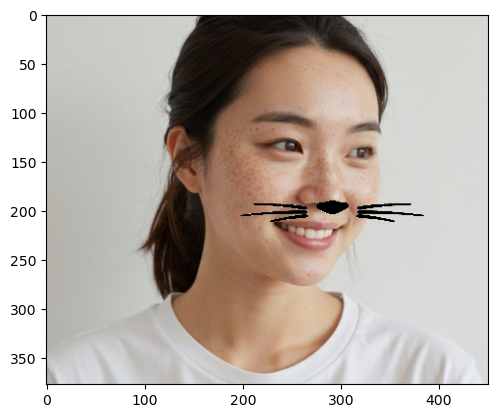

In [142]:
# 이미지에 수정된 sticker3_crop 이미지 적용하여 합치기 

sticker_area3 = img3_show[refined_y3:refined_y3+img_sticker3_crop.shape[0], refined_x3:refined_x3+img_sticker3_crop.shape[1]]

img3_show[refined_y3:refined_y3+img_sticker3_crop.shape[0], refined_x3:refined_x3+img_sticker3_crop.shape[1]] = \
    np.where(img_sticker3_crop==255, sticker_area3, img_sticker3_crop).astype(np.uint8)

plt.imshow(cv2.cvtColor(img3_show, cv2.COLOR_BGR2RGB))
plt.show()

7. 디버깅 통해 문제 해결 확인하였으며, 첫번째 이미지에도 적용하여 검증 시도.

(438, 156)


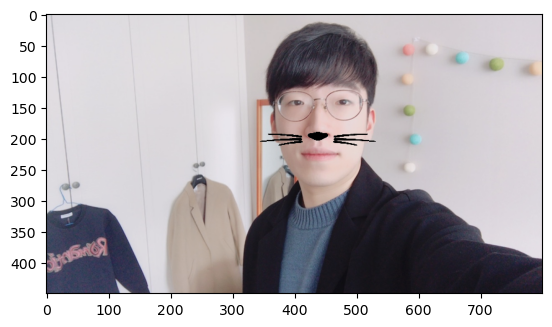

In [145]:
# 첫번째 이미지의 코 위치 좌표 업데이트 적용
img_show = cv2.imread(my_image_path)                        # 이미지 초기화

for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴영역 정보를 가진 dlib_rect 변수와 랜드마크 값을 가진 list_landmarks 변수로 반복문 수행.
    print (landmark[28])                                    # 코 위치 index = 28
    x = landmark[28][0]                                     # 코 위치 x값
    y = landmark[28][1]                                     # 코 위치 y값  
    w = dlib_rect.width()                                   # 얼굴영역의 가로부위 픽셀 수 = (531-345+1) → max(x) - min(x) +1 (픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    h = round(dlib_rect.width()/2)  

refined_x = x - w // 2      
refined_y = y + int(h//7) 


# 첫번째 이미지에 수정된 sticker_crop 이미지 적용하여 합치기 
sticker_area_rev = img_show[refined_y:refined_y+img_sticker3_crop.shape[0], refined_x:refined_x+img_sticker3_crop.shape[1]]

img_show[refined_y:refined_y+img_sticker3_crop.shape[0], refined_x:refined_x+img_sticker3_crop.shape[1]] = \
    np.where(img_sticker3_crop==255, sticker_area_rev, img_sticker3_crop).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

8. 코수염 위치 정상 작동 확인 완료.